In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### DATA LOADING

In [31]:
""""
kolom = ['BI-RADS Assesment', 'Age', 'Shape', 'Margin', 'Density', 'Severity']
df = pd.read_csv('/content/mammographic_masses.data', header=None, names=kolom, na_values=['?'])
df.head()
"""

'"\nkolom = [\'BI-RADS Assesment\', \'Age\', \'Shape\', \'Margin\', \'Density\', \'Severity\']\ndf = pd.read_csv(\'/content/mammographic_masses.data\', header=None, names=kolom, na_values=[\'?\'])\ndf.head()\n'

### EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
kolom = ['BI-RADS Assesment', 'Age', 'Shape', 'Margin', 'Density', 'Severity']
df = pd.read_csv('dataset/mammographic_masses.data', header=None, names=kolom, na_values=['?'])
df.head()

,BI-RADS Assesment,Age,Shape,Margin,Density,Severity
0,5.0,67.0,3.0,5.0,3.0,1
1,4.0,43.0,1.0,1.0,NaN,1
2,5.0,58.0,4.0,5.0,3.0,1
3,4.0,28.0,1.0,1.0,3.0,0
4,5.0,74.0,1.0,5.0,NaN,1


DATA PREPROCESSING

In [33]:
df.isnull().sum()

BI-RADS Assesment     2
Age                   5
Shape                31
Margin               48
Density              76
Severity              0
dtype: int64

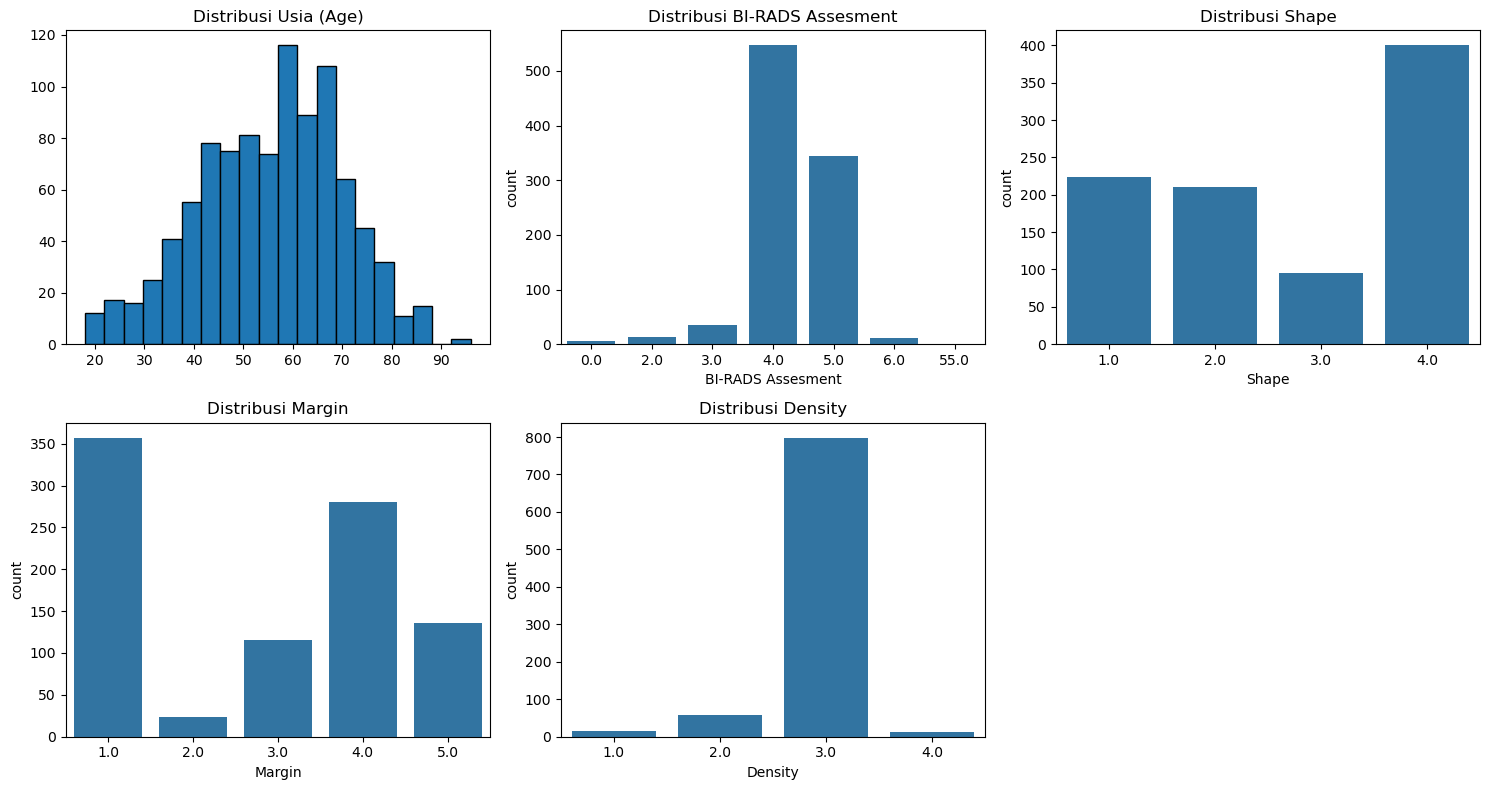

In [34]:
cols = ['BI-RADS Assesment','Shape', 'Margin', 'Density']
# Perbesar ukuran grafik agar muat 5 plot (2 baris, 3 kolom)
plt.figure(figsize=(15, 8))

# 1. Plot pertama untuk 'Age' (Usia) taruh di posisi 1
plt.subplot(2, 3, 1)
plt.hist(df['Age'].dropna(), bins=20, edgecolor='black')
plt.title('Distribusi Usia (Age)')

# 2. Looping untuk kolom kategori, mulai taruh dari posisi 2 dan seterusnya
for i, col in enumerate(cols):
    # (i + 2) karena grafik Age sudah ambil posisi 1
    # Jadi ini akan mengisi posisi 2, 3, 4, 5
    plt.subplot(2, 3, i + 2)
    sns.countplot(x=df[col].dropna())
    plt.title(f"Distribusi {col}")

# Merapikan jarak antar grafik agar tidak tumpang tindih
plt.tight_layout()
plt.show()

### DATA PREPROCESSING

In [35]:
df['BI-RADS Assesment'] = df['BI-RADS Assesment'].replace(55.0, 5.0)

cols = ['BI-RADS Assesment', 'Age', 'Shape', 'Margin', 'Density', 'Severity']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

kolom_kategori = ['BI-RADS Assesment', 'Shape', 'Margin', 'Density']
for col in kolom_kategori:
    modus = df[col].mode()[0]
    df[col].fillna(modus, inplace=True)

median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

print(df.isnull().sum())

BI-RADS Assesment    0
Age                  0
Shape                0
Margin               0
Density              0
Severity             0
dtype: int64


/tmp/ipykernel_140987/2974326029.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(modus, inplace=True)
/tmp/ipykernel_140987/2974326029.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

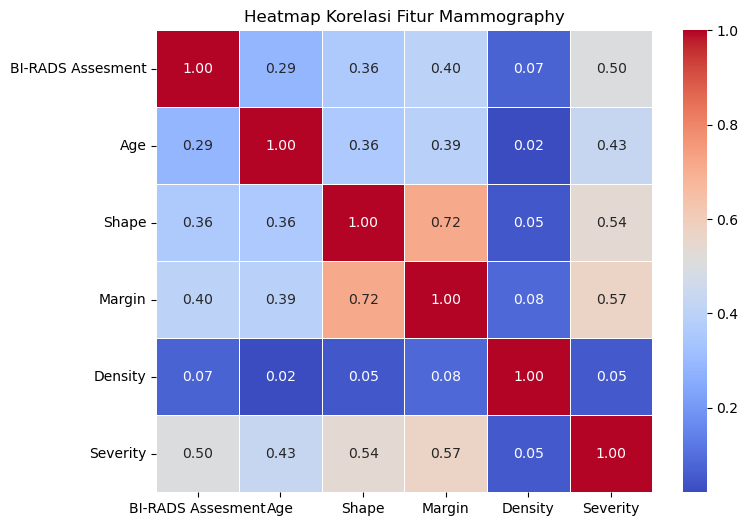

In [36]:

kolom_korelasi = ['BI-RADS Assesment', 'Age', 'Shape', 'Margin', 'Density', 'Severity']

plt.figure(figsize=(8, 6))
sns.heatmap(df[kolom_korelasi].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Mammography')
plt.show()

### FEATURE ENGINEERING

In [37]:
def one_hot_encode_np(values, prefix):
    """One-hot encoding from scratch untuk fitur kategorikal."""
    values = np.asarray(values, dtype=int)
    categories = np.sort(np.unique(values))
    encoded = (values[:, None] == categories[None, :]).astype(float)
    feature_names = [f'{prefix}_{category}' for category in categories]
    return encoded, feature_names


def build_feature_matrix(df):
    """Membangun matriks fitur dengan campuran fitur numerik dan kategorikal."""
    birads = df['BI-RADS Assesment'].to_numpy(dtype=float).reshape(-1, 1)
    age = df['Age'].to_numpy(dtype=float).reshape(-1, 1)
    shape_encoded, shape_feature_names = one_hot_encode_np(df['Shape'].to_numpy(), 'Shape')
    margin_encoded, margin_feature_names = one_hot_encode_np(df['Margin'].to_numpy(), 'Margin')

    age_squared = age ** 2
    birads_age_interaction = birads * age

    X = np.hstack([
        birads,
        age,
        age_squared,
        birads_age_interaction,
        shape_encoded,
        margin_encoded,
    ])

    feature_names = [
        'BI-RADS Assesment',
        'Age',
        'Age^2',
        'BI-RADS Assesment * Age',
        *shape_feature_names,
        *margin_feature_names,
    ]
    return X, feature_names

In [38]:
kolom_features_terbaik = ['BI-RADS Assesment', 'Age', 'Shape', 'Margin']
X_data, engineered_feature_names = build_feature_matrix(df)
y_data = df['Severity'].to_numpy(dtype=int)

### SPLITTING AND SCALING UTILITIES

In [39]:
def add_feature_interactions(X, feature_names):
    """Menambahkan fitur interaksi sederhana secara manual."""
    X = np.asarray(X, dtype=float)
    feature_names = list(feature_names)

    engineered_features = [X]
    engineered_names = feature_names.copy()
    feature_index = {name: idx for idx, name in enumerate(feature_names)}

    interaction_pairs = [
        ('BI-RADS Assesment', 'Age'),
        ('Shape', 'Margin'),
        ('Age', 'Shape'),
    ]

    for left_name, right_name in interaction_pairs:
        interaction = (
            X[:, feature_index[left_name]] * X[:, feature_index[right_name]]
        ).reshape(-1, 1)
        engineered_features.append(interaction)
        engineered_names.append(f'{left_name} * {right_name}')

    age_squared = (X[:, feature_index['Age']] ** 2).reshape(-1, 1)
    engineered_features.append(age_squared)
    engineered_names.append('Age^2')

    return np.hstack(engineered_features), engineered_names


X_data, engineered_feature_names = add_feature_interactions(X_data, kolom_features_terbaik)

In [40]:
X_data, engineered_feature_names = add_feature_interactions(X_data, kolom_features_terbaik)

print(df[kolom_features_terbaik].to_numpy(dtype=float).shape)
print(X_data.shape)
print(engineered_feature_names)

(961, 4)
(961, 21)
['BI-RADS Assesment', 'Age', 'Shape', 'Margin', 'BI-RADS Assesment * Age', 'Shape * Margin', 'Age * Shape', 'Age^2']


In [41]:
def train_test_split_np(X, y, test_size=0.2, shuffle=True, random_state=42):
    """Membagi data menjadi train dan test hanya dengan NumPy."""
    X = np.asarray(X)
    y = np.asarray(y)

    if len(X) != len(y):
        raise ValueError('Panjang X dan y harus sama.')

    n_samples = len(X)
    if isinstance(test_size, float):
        if not 0 < test_size < 1:
            raise ValueError('test_size float harus berada di rentang (0, 1).')
        n_test = int(np.ceil(n_samples * test_size))
    else:
        n_test = int(test_size)

    if n_test <= 0 or n_test >= n_samples:
        raise ValueError('Ukuran test set tidak valid.')

    indices = np.arange(n_samples)
    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)

    test_idx = indices[:n_test]
    train_idx = indices[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [42]:
""""
batas = int(0.8 * len(X_data))
X_train, X_test = X_data[:batas], X_data[batas:]
y_train, y_test = y_data[:batas], y_data[batas:]
"""

'"\nbatas = int(0.8 * len(X_data))\nX_train, X_test = X_data[:batas], X_data[batas:]\ny_train, y_test = y_data[:batas], y_data[batas:]\n'

In [43]:
class MinMaxScaler:
    def __init__(self):
        self.min_ = None
        self.max_ = None
        self.range_ = None

    def fit(self, X):
        """Mencari nilai minimum dan maksimum tiap kolom dari data train."""
        X = np.asarray(X, dtype=float)
        self.min_ = np.min(X, axis=0)
        self.max_ = np.max(X, axis=0)
        self.range_ = np.where((self.max_ - self.min_) == 0, 1.0, self.max_ - self.min_)
        return self

    def transform(self, X):
        """Menerapkan rumus (X - min) / (max - min)."""
        if self.min_ is None or self.range_ is None:
            raise ValueError('Jalankan fit() terlebih dahulu sebelum transform().')

        X = np.asarray(X, dtype=float)
        return (X - self.min_) / self.range_

    def fit_transform(self, X):
        """Melakukan fit dan transform sekaligus dalam satu langkah."""
        return self.fit(X).transform(X)

In [44]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        """Standarisasi fitur dengan mean 0 dan deviasi standar 1."""
        X = np.asarray(X, dtype=float)
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self.std_ = np.where(self.std_ == 0, 1.0, self.std_)
        return self

    def transform(self, X):
        if self.mean_ is None or self.std_ is None:
            raise ValueError('Jalankan fit() terlebih dahulu sebelum transform().')

        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

### MODEL IMPLEMENTATION

In [45]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000, lambda_=0):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.lambda_ = lambda_
        self.weights = None
        self.bias = None
        self.cost_history = []

    def _sigmoid(self, x):
        """Sigmoid stabil secara numerik untuk array atau scalar."""
        x = np.asarray(x, dtype=float)
        out = np.empty_like(x, dtype=float)

        positive_mask = x >= 0
        negative_mask = ~positive_mask

        out[positive_mask] = 1.0 / (1.0 + np.exp(-x[positive_mask]))
        exp_x = np.exp(x[negative_mask])
        out[negative_mask] = exp_x / (1.0 + exp_x)
        return out

    def _compute_loss(self, y_true, y_prob):
        """Binary cross-entropy dengan clipping untuk mencegah log(0)."""
        y_true = np.asarray(y_true, dtype=float)
        y_prob = np.clip(np.asarray(y_prob, dtype=float), 1e-12, 1 - 1e-12)
        base_loss = -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
        reg_loss = (self.lambda_ / (2 * len(y_true))) * np.sum(self.weights ** 2)
        return base_loss + reg_loss

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features, dtype=float)
        self.bias = 0.0
        self.cost_history = []

        for _ in range(self.n_iters):
            linear_model = X @ self.weights + self.bias
            y_predicted = self._sigmoid(linear_model)

            error = y_predicted - y
            dw = (X.T @ error) / n_samples
            dw += (self.lambda_ / n_samples) * self.weights
            db = np.sum(error) / n_samples

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            self.cost_history.append(self._compute_loss(y, y_predicted))

        return self

    def predict_prob(self, X):
        X = np.asarray(X, dtype=float)
        linear_model = X @ self.weights + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        y_predicted = self.predict_prob(X)
        return (y_predicted >= threshold).astype(int)


In [46]:
class ModelEvaluator:
    @staticmethod
    def _safe_divide(numerator, denominator):
        numerator = np.asarray(numerator, dtype=float)
        denominator = np.asarray(denominator, dtype=float)
        result = np.zeros_like(numerator, dtype=float)
        np.divide(numerator, denominator, out=result, where=denominator != 0)
        return result

    @staticmethod
    def get_confusion_matrix(y_true, y_pred):
        """Menghasilkan TP, TN, FP, FN."""
        y_true = np.asarray(y_true, dtype=int)
        y_pred = np.asarray(y_pred, dtype=int)

        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        return tp, tn, fp, fn

    @classmethod
    def calculate_metrics(cls, y_true, y_pred):
        tp, tn, fp, fn = cls.get_confusion_matrix(y_true, y_pred)
        accuracy = cls._safe_divide(tp + tn, len(y_true)).item()
        precision = cls._safe_divide(tp, tp + fp).item()
        recall = cls._safe_divide(tp, tp + fn).item()
        f1_score = cls._safe_divide(2 * precision * recall, precision + recall).item()
        specificity = cls._safe_divide(tn, tn + fp).item()

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1_score,
            'specificity': specificity,
            'tp': int(tp),
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
        }

    @classmethod
    def threshold_metrics(cls, y_true, probabilities, thresholds=None):
        y_true = np.asarray(y_true, dtype=int)
        probabilities = np.asarray(probabilities, dtype=float)
        if thresholds is None:
            thresholds = np.arange(0.01, 1.0, 0.01)
        thresholds = np.asarray(thresholds, dtype=float)

        pred_matrix = (probabilities[:, None] >= thresholds[None, :]).astype(int)
        positive_mask = (y_true[:, None] == 1)
        negative_mask = ~positive_mask

        tp = np.sum(pred_matrix & positive_mask, axis=0)
        fp = np.sum(pred_matrix & negative_mask, axis=0)
        fn = np.sum((1 - pred_matrix) & positive_mask, axis=0)
        tn = np.sum((1 - pred_matrix) & negative_mask, axis=0)

        precision = cls._safe_divide(tp, tp + fp)
        recall = cls._safe_divide(tp, tp + fn)
        f1 = cls._safe_divide(2 * precision * recall, precision + recall)
        accuracy = cls._safe_divide(tp + tn, tp + tn + fp + fn)
        specificity = cls._safe_divide(tn, tn + fp)
        fpr = 1 - specificity

        return {
            'thresholds': thresholds,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'accuracy': accuracy,
            'specificity': specificity,
            'fpr': fpr,
            'tp': tp,
            'tn': tn,
            'fp': fp,
            'fn': fn,
        }

    @classmethod
    def find_best_threshold(cls, model, X_eval, y_eval, method='f1', target_recall=0.95):
        probabilities = model.predict_prob(X_eval)
        metrics = cls.threshold_metrics(y_eval, probabilities)
        thresholds = metrics['thresholds']

        if method == 'f1':
            best_idx = int(np.argmax(metrics['f1']))
            return float(thresholds[best_idx])

        if method == 'recall':
            valid_idx = np.where(metrics['recall'] >= target_recall)[0]
            if valid_idx.size == 0:
                fallback_idx = int(np.argmax(metrics['recall']))
                return float(thresholds[fallback_idx])
            return float(thresholds[valid_idx[-1]])

        raise ValueError("method harus 'f1' atau 'recall'.")

    @classmethod
    def print_report(cls, y_true, y_pred, threshold_info=None):
        metrics = cls.calculate_metrics(y_true, y_pred)

        if threshold_info is not None:
            print(f"=== LAPORAN EVALUASI (Threshold: {threshold_info}) ===")
        else:
            print('=== LAPORAN EVALUASI MODEL ===')

        print(
            f"Confusion Matrix : TP={metrics['tp']} | TN={metrics['tn']} | FP={metrics['fp']} | FN={metrics['fn']}"
        )
        print('-' * 40)
        print(f"Akurasi          : {metrics['accuracy']:.4f}")
        print(f"Recall           : {metrics['recall']:.4f}")
        print(f"Precision        : {metrics['precision']:.4f}")
        print(f"Specificity      : {metrics['specificity']:.4f}")
        print(f"F1-Score         : {metrics['f1']:.4f}\n")
        return metrics

    @staticmethod
    def plot_correlation(df, features, target_col='Severity'):
        """Plot utama 1: heatmap korelasi fitur dan target."""
        corr = df[features + [target_col]].corr()
        plt.figure(figsize=(9, 7))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
        plt.title('Heatmap Korelasi Fitur dan Target')
        plt.tight_layout()
        plt.show()

    @classmethod
    def plot_precision_recall_curve(cls, model, X_eval, y_eval, current_t=0.5):
        """Plot utama 2: precision-recall curve."""
        probabilities = model.predict_prob(X_eval)
        metrics = cls.threshold_metrics(y_eval, probabilities)

        plt.figure(figsize=(8, 6))
        plt.plot(metrics['recall'], metrics['precision'], color='blue', linewidth=2, label='PR Curve')

        current_pred = model.predict(X_eval, threshold=current_t)
        current_metrics = cls.calculate_metrics(y_eval, current_pred)
        plt.scatter(
            current_metrics['recall'],
            current_metrics['precision'],
            color='red',
            s=90,
            label=f'Threshold aktif = {current_t:.2f}',
            zorder=5,
        )

        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()

    @classmethod
    def plot_confusion_matrix(cls, y_true, y_pred):
        """Plot utama 3: heatmap confusion matrix."""
        metrics = cls.calculate_metrics(y_true, y_pred)
        cm = np.array([[metrics['tn'], metrics['fp']], [metrics['fn'], metrics['tp']]])

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'],
        )
        plt.title('Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

    @classmethod
    def plot_roc_curve(cls, model, X_eval, y_eval, current_t=0.5):
        """Plot ROC curve dari threshold sweep berbasis NumPy."""
        probabilities = model.predict_prob(X_eval)
        metrics = cls.threshold_metrics(y_eval, probabilities, thresholds=np.linspace(0, 1, 201))
        order = np.argsort(metrics['fpr'])
        fpr = metrics['fpr'][order]
        tpr = metrics['recall'][order]
        auc = np.trapz(tpr, fpr)

        current_pred = model.predict(X_eval, threshold=current_t)
        current_metrics = cls.calculate_metrics(y_eval, current_pred)
        current_fpr = 1 - current_metrics['specificity']

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, linewidth=2, color='darkorange', label=f'ROC Curve (AUC = {auc:.3f})')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
        plt.scatter(
            current_fpr,
            current_metrics['recall'],
            color='red',
            s=90,
            label=f'Threshold aktif = {current_t:.2f}',
        )
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate (Recall)')
        plt.title('ROC Curve')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()

    @classmethod
    def plot_threshold_tradeoff(cls, model, X_eval, y_eval):
        """Plot hubungan threshold dengan precision, recall, dan F1."""
        probabilities = model.predict_prob(X_eval)
        metrics = cls.threshold_metrics(y_eval, probabilities)

        plt.figure(figsize=(10, 6))
        plt.plot(metrics['thresholds'], metrics['precision'], label='Precision', linewidth=2)
        plt.plot(metrics['thresholds'], metrics['recall'], label='Recall', linewidth=2)
        plt.plot(metrics['thresholds'], metrics['f1'], label='F1-Score', linewidth=2)
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.title('Trade-off Threshold vs Precision / Recall / F1')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_probability_distribution(y_true, probabilities):
        """Plot bonus: distribusi probabilitas prediksi untuk kelas 0 dan 1."""
        y_true = np.asarray(y_true, dtype=int)
        probabilities = np.asarray(probabilities, dtype=float)

        plt.figure(figsize=(10, 6))
        plt.hist(
            probabilities[y_true == 0],
            bins=15,
            alpha=0.6,
            label='Severity = 0',
            color='steelblue',
            edgecolor='black',
        )
        plt.hist(
            probabilities[y_true == 1],
            bins=15,
            alpha=0.6,
            label='Severity = 1',
            color='salmon',
            edgecolor='black',
        )
        plt.xlabel('Probabilitas Prediksi Kelas 1')
        plt.ylabel('Jumlah Sampel')
        plt.title('Distribusi Probabilitas Prediksi per Kelas')
        plt.legend()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_training_history(model):
        """Plot bonus: kurva loss gradient descent."""
        if not getattr(model, 'cost_history', None):
            raise ValueError('Model belum memiliki riwayat loss.')

        plt.figure(figsize=(8, 5))
        plt.plot(model.cost_history, color='darkgreen', linewidth=2)
        plt.title('Training Loss per Iterasi')
        plt.xlabel('Iterasi')
        plt.ylabel('Binary Cross-Entropy Loss')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

### VALIDATION UTILITIES

In [47]:
def k_fold_validator(
    X,
    y,
    model_class,
    k=5,
    scaler_class=StandardScaler,
    use_scaler=True,
    random_state=42,
    **model_kwargs,
):
    """Fungsi K-Fold universal yang mencegah data leakage."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int)
    n_samples = len(X)

    if k < 2 or k > n_samples:
        raise ValueError('Nilai k harus berada di antara 2 dan jumlah sampel.')

    indices = np.arange(n_samples)
    rng = np.random.default_rng(random_state)
    rng.shuffle(indices)
    fold_indices = np.array_split(indices, k)

    accuracies = []
    print(f'=== Memulai {k}-Fold Validation ===')

    for fold_number, test_idx in enumerate(fold_indices, start=1):
        train_idx = np.concatenate([idx for idx in fold_indices if not np.array_equal(idx, test_idx)])
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]

        if use_scaler:
            scaler = scaler_class()
            X_train_fold = scaler.fit_transform(X_train_fold)
            X_test_fold = scaler.transform(X_test_fold)

        model = model_class(**model_kwargs)
        model.fit(X_train_fold, y_train_fold)
        predictions = model.predict(X_test_fold)

        acc = np.mean(predictions == y_test_fold)
        accuracies.append(acc)
        print(f'Fold {fold_number} | Akurasi: {acc:.4f}')

    mean_acc = float(np.mean(accuracies))
    print('-' * 35)
    print(f'Rata-rata Akurasi: {mean_acc:.4f}\n')
    return mean_acc

In [48]:
def grid_search_cv(
    X,
    y,
    model_class,
    param_grid,
    k=5,
    scaler_class=StandardScaler,
    use_scaler=True,
    random_state=42,
):
    """Mencari kombinasi parameter terbaik secara manual tanpa scikit-learn."""
    print('=== MEMULAI GRID SEARCH ===')

    best_akurasi = -np.inf
    best_params = {}
    all_results = []

    keys = list(param_grid.keys())
    values = list(param_grid.values())

    def get_combinations(items):
        combinations = [[]]
        for item in items:
            combinations = [base + [candidate] for base in combinations for candidate in item]
        return combinations

    for combo in get_combinations(values):
        params = dict(zip(keys, combo))
        print(f'\n[Menguji] {params}')

        akurasi_rata_rata = k_fold_validator(
            X=X,
            y=y,
            model_class=model_class,
            k=k,
            scaler_class=scaler_class,
            use_scaler=use_scaler,
            random_state=random_state,
            **params,
        )

        all_results.append({'params': params, 'accuracy': akurasi_rata_rata})

        if akurasi_rata_rata > best_akurasi:
            best_akurasi = akurasi_rata_rata
            best_params = params

    print('\n' + '=' * 45)
    print('HASIL AKHIR GRID SEARCH')
    print(f'Setelan Terbaik : {best_params}')
    print(f'Akurasi Puncak  : {best_akurasi:.4f}')
    print('=' * 45)
    return best_params, all_results


In [49]:
def plot_grid_search_results(results_list):
    """Menampilkan bar chart perbandingan akurasi tiap kombinasi parameter."""
    labels = [str(r['params']) for r in results_list]
    accuracies = [r['accuracy'] for r in results_list]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, accuracies, color='skyblue', edgecolor='navy')

    mean_acc = np.mean(accuracies)
    plt.axhline(mean_acc, color='red', linestyle='--', label=f'Rata-rata ({mean_acc:.4f})')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom')

    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Akurasi Rata-rata (K-Fold)')
    plt.title('Perbandingan Performa Kombinasi Parameter (Grid Search)')
    plt.ylim(min(accuracies) - 0.05, max(accuracies) + 0.05)
    plt.legend()
    plt.tight_layout()
    plt.show()

### BASELINE RESULTS

In [50]:
X_train_full, X_test, y_train_full, y_test = train_test_split_np(
    X_data, y_data, test_size=0.2, shuffle=True, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split_np(
    X_train_full, y_train_full, test_size=0.25, shuffle=True, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

baseline_params = {
    'learning_rate': 0.01,
    'n_iters': 1500,
    'lambda_': 0.0,
}

baseline_model = LogisticRegression(**baseline_params)
baseline_model.fit(X_train_scaled, y_train)

baseline_val_pred = baseline_model.predict(X_val_scaled, threshold=0.5)
baseline_test_pred = baseline_model.predict(X_test_scaled, threshold=0.5)

print('=== HASIL BASELINE MODEL ===')
print(f'Parameter baseline: {baseline_params}')
baseline_val_metrics = ModelEvaluator.print_report(
    y_val,
    baseline_val_pred,
    threshold_info='0.50 (Baseline Validation)',
)
baseline_test_metrics = ModelEvaluator.print_report(
    y_test,
    baseline_test_pred,
    threshold_info='0.50 (Baseline Test)',
)



=== HASIL BASELINE MODEL ===
Parameter baseline: {'learning_rate': 0.01, 'n_iters': 1500, 'lambda_': 0.0}
=== LAPORAN EVALUASI (Threshold: 0.50 (Baseline Validation)) ===
Confusion Matrix : TP=68 | TN=91 | FP=16 | FN=17
----------------------------------------
Akurasi          : 0.8281
Recall           : 0.8000
Precision        : 0.8095
Specificity      : 0.8505
F1-Score         : 0.8047

=== LAPORAN EVALUASI (Threshold: 0.50 (Baseline Test)) ===
Confusion Matrix : TP=78 | TN=81 | FP=14 | FN=20
----------------------------------------
Akurasi          : 0.8238
Recall           : 0.7959
Precision        : 0.8478
Specificity      : 0.8526
F1-Score         : 0.8211



### RESULT VALIDATION

=== MEMULAI GRID SEARCH ===

[Menguji] {'learning_rate': 0.1, 'n_iters': 1500, 'lambda_': 0.0}
=== Memulai 5-Fold Validation ===
Fold 1 | Akurasi: 0.8187


Fold 2 | Akurasi: 0.7812
Fold 3 | Akurasi: 0.8542
Fold 4 | Akurasi: 0.8073
Fold 5 | Akurasi: 0.8646
-----------------------------------
Rata-rata Akurasi: 0.8252


[Menguji] {'learning_rate': 0.1, 'n_iters': 1500, 'lambda_': 0.01}
=== Memulai 5-Fold Validation ===
Fold 1 | Akurasi: 0.8187
Fold 2 | Akurasi: 0.7812
Fold 3 | Akurasi: 0.8542
Fold 4 | Akurasi: 0.8073
Fold 5 | Akurasi: 0.8646
-----------------------------------
Rata-rata Akurasi: 0.8252


[Menguji] {'learning_rate': 0.1, 'n_iters': 1500, 'lambda_': 0.1}
=== Memulai 5-Fold Validation ===
Fold 1 | Akurasi: 0.8187
Fold 2 | Akurasi: 0.7812
Fold 3 | Akurasi: 0.8542
Fold 4 | Akurasi: 0.8073
Fold 5 | Akurasi: 0.8646
-----------------------------------
Rata-rata Akurasi: 0.8252


[Menguji] {'learning_rate': 0.1, 'n_iters': 2500, 'lambda_': 0.0}
=== Memulai 5-Fold Validation ===
Fold 1 | Akurasi: 0.8187
Fold 2 | Akurasi: 0.7812
Fold 3 | Akurasi: 0.8542
Fold 4 | Akurasi: 0.8021
Fold 5 | Akurasi: 0.8594
--------------------------------

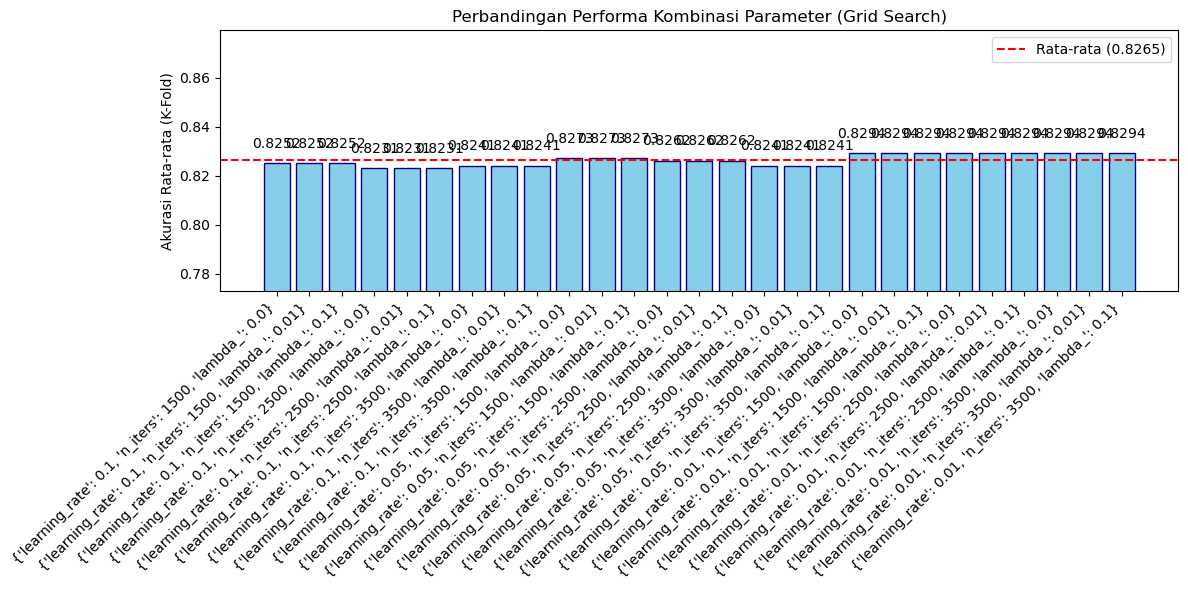

In [51]:
param_grid_logreg = {
    'learning_rate': [0.1, 0.05, 0.01],
    'n_iters': [1500, 2500, 3500],
    'lambda_': [0.0, 0.01, 0.1],
}

setelan_terbaik, riwayat_pencarian = grid_search_cv(
    X=X_data,
    y=y_data,
    model_class=LogisticRegression,
    param_grid=param_grid_logreg,
    k=5,
    scaler_class=StandardScaler,
    use_scaler=True,
)

plot_grid_search_results(riwayat_pencarian)

### FINAL TUNED MODEL

In [52]:
model_final = LogisticRegression(**setelan_terbaik)
model_final.fit(X_train_scaled, y_train)

tuned_val_pred_default = model_final.predict(X_val_scaled, threshold=0.5)
ModelEvaluator.print_report(
    y_val,
    tuned_val_pred_default,
    threshold_info='0.50 (Tuned Validation Default)',
)


t_optimal = ModelEvaluator.find_best_threshold(model_final, X_val_scaled, y_val, method='f1')
t_medis = ModelEvaluator.find_best_threshold(
    model_final, X_val_scaled, y_val, method='recall', target_recall=0.90
)

print(f'Threshold Optimal (F1, validation)   : {t_optimal:.2f}')
print(f'Threshold Medis (Recall, validation) : {t_medis:.2f}')

y_pred_final = model_final.predict(X_test_scaled, threshold=t_medis)
y_prob_test = model_final.predict_prob(X_test_scaled)
final_metrics = ModelEvaluator.print_report(
    y_test,
    y_pred_final,
    threshold_info=f'{t_medis:.2f} (Test Set, tuned on validation)',
)

=== LAPORAN EVALUASI (Threshold: 0.50 (Tuned Validation Default)) ===
Confusion Matrix : TP=67 | TN=92 | FP=15 | FN=18
----------------------------------------
Akurasi          : 0.8281
Recall           : 0.7882
Precision        : 0.8171
Specificity      : 0.8598
F1-Score         : 0.8024

Threshold Optimal (F1, validation)   : 0.45
Threshold Medis (Recall, validation) : 0.27
=== LAPORAN EVALUASI (Threshold: 0.27 (Test Set, tuned on validation)) ===
Confusion Matrix : TP=86 | TN=72 | FP=23 | FN=12
----------------------------------------
Akurasi          : 0.8187
Recall           : 0.8776
Precision        : 0.7890
Specificity      : 0.7579
F1-Score         : 0.8309



In [53]:
def plot_baseline_vs_tuned(baseline_metrics, tuned_metrics):
    """Membandingkan metrik baseline dan model hasil tuning."""
    metric_names = ['accuracy', 'precision', 'recall', 'f1', 'specificity']
    baseline_scores = [baseline_metrics[name] for name in metric_names]
    tuned_scores = [tuned_metrics[name] for name in metric_names]

    labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity']
    positions = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(positions - width / 2, baseline_scores, width=width, label='Baseline', color='lightcoral')
    plt.bar(positions + width / 2, tuned_scores, width=width, label='Tuned', color='seagreen')

    for idx, score in enumerate(baseline_scores):
        plt.text(positions[idx] - width / 2, score + 0.01, f'{score:.3f}', ha='center', va='bottom')

    for idx, score in enumerate(tuned_scores):
        plt.text(positions[idx] + width / 2, score + 0.01, f'{score:.3f}', ha='center', va='bottom')

    plt.xticks(positions, labels)
    plt.ylim(0, 1.1)
    plt.ylabel('Score')
    plt.title('Perbandingan Performa Baseline vs Tuned Model')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()



### RESULT COMPARISON

In [54]:
print('=== PERBANDINGAN BASELINE VS TUNED ===')
print(
    f"Baseline Test Accuracy: {baseline_test_metrics['accuracy']:.4f} | "
    f"Tuned Test Accuracy: {final_metrics['accuracy']:.4f}"
)
print(
    f"Baseline Test Recall: {baseline_test_metrics['recall']:.4f} | "
    f"Tuned Test Recall: {final_metrics['recall']:.4f}"
)
print(
    f"Baseline Test F1: {baseline_test_metrics['f1']:.4f} | "
    f"Tuned Test F1: {final_metrics['f1']:.4f}"
)



=== PERBANDINGAN BASELINE VS TUNED ===
Baseline Test Accuracy: 0.8238 | Tuned Test Accuracy: 0.8187
Baseline Test Recall: 0.7959 | Tuned Test Recall: 0.8776
Baseline Test F1: 0.8211 | Tuned Test F1: 0.8309


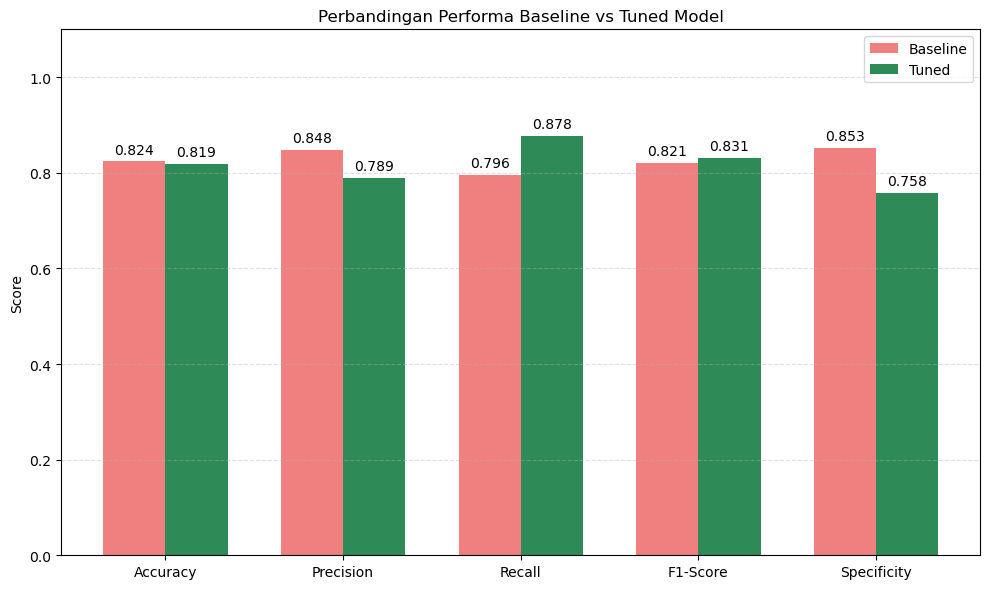

In [55]:
plot_baseline_vs_tuned(baseline_test_metrics, final_metrics)

### FINAL MODEL VISUALIZATIONS


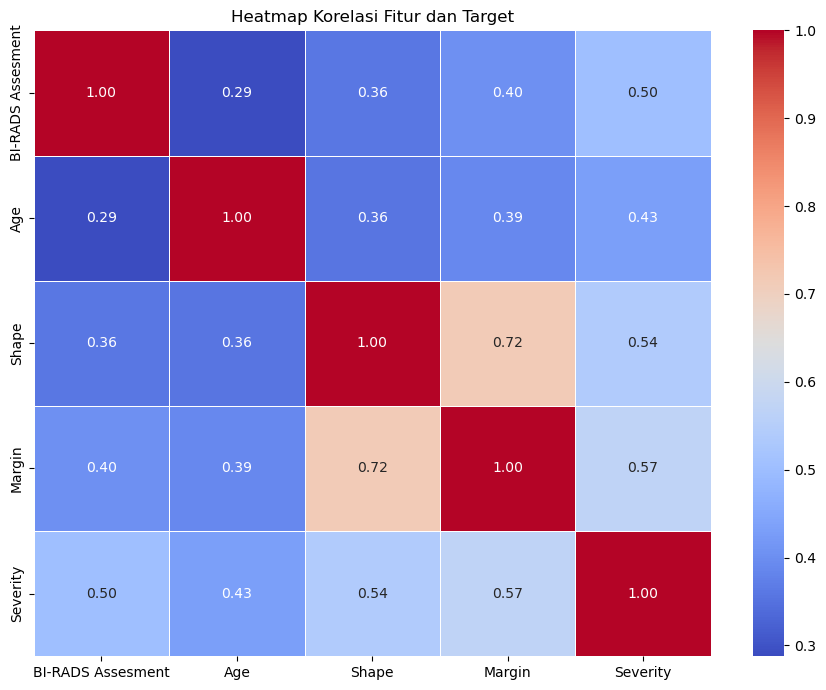

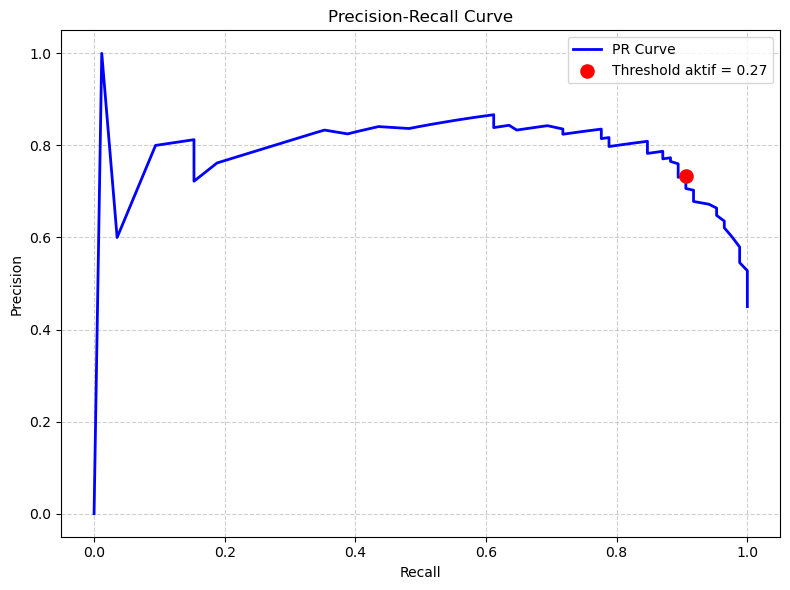

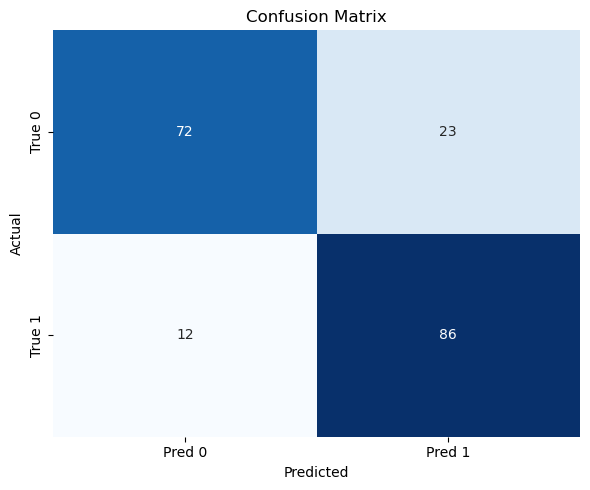

In [56]:
ModelEvaluator.plot_correlation(df, kolom_features_terbaik)
ModelEvaluator.plot_precision_recall_curve(model_final, X_val_scaled, y_val, current_t=t_medis)
ModelEvaluator.plot_confusion_matrix(y_test, y_pred_final)


/tmp/ipykernel_140987/2605242661.py:188: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


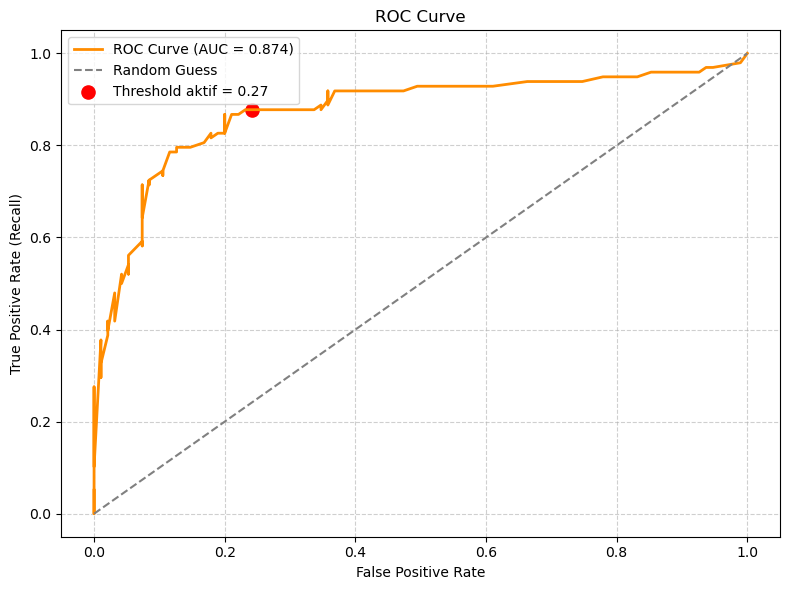

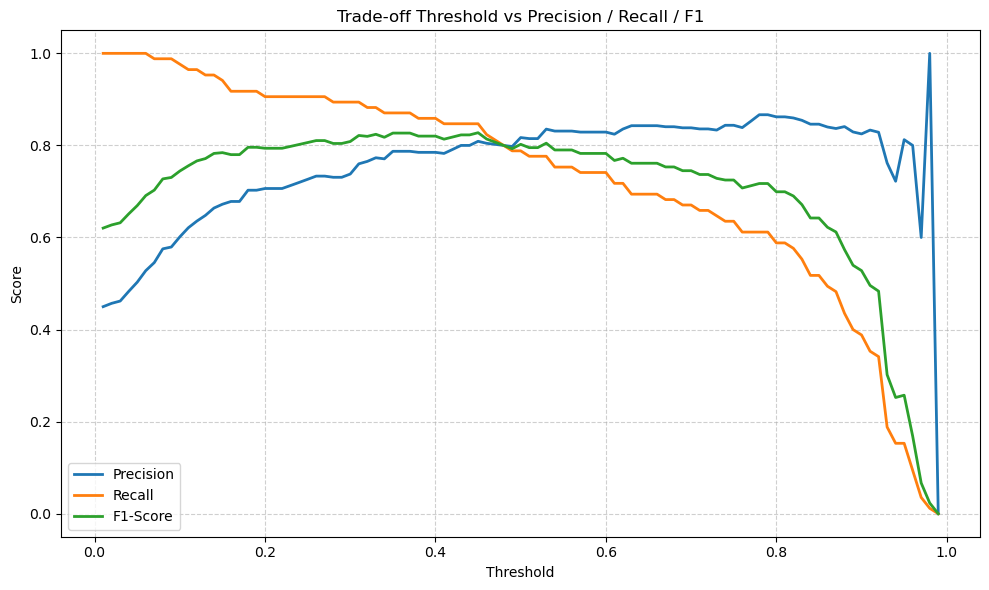

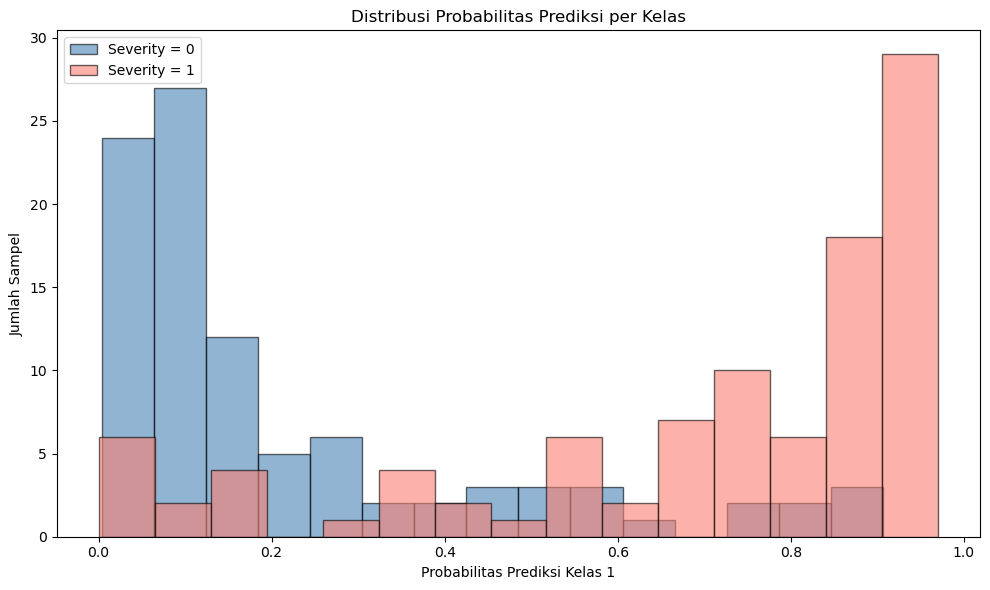

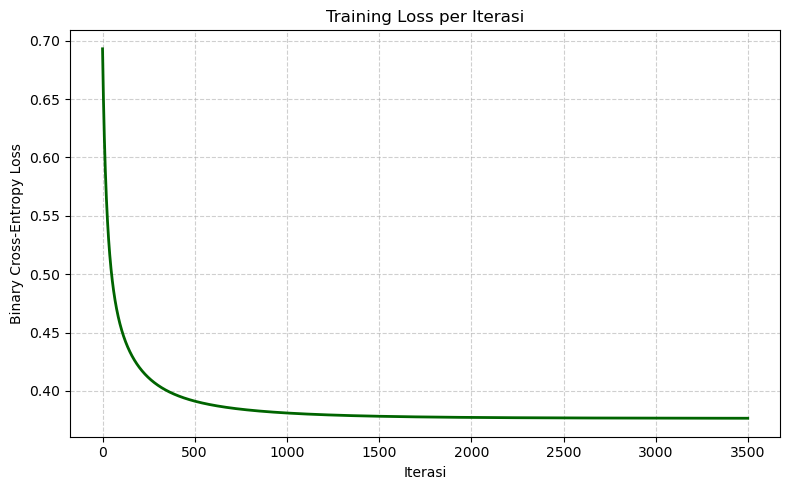

In [57]:
ModelEvaluator.plot_roc_curve(model_final, X_test_scaled, y_test, current_t=t_medis)
ModelEvaluator.plot_threshold_tradeoff(model_final, X_val_scaled, y_val)
ModelEvaluator.plot_probability_distribution(y_test, y_prob_test)
ModelEvaluator.plot_training_history(model_final)

In [58]:
final_metrics

{'accuracy': 0.8186528497409327,
 'precision': 0.7889908256880734,
 'recall': 0.8775510204081632,
 'f1': 0.8309178743961353,
 'specificity': 0.7578947368421053,
 'tp': 86,
 'tn': 72,
 'fp': 23,
 'fn': 12}